## 1. uzdevums. Kursa sintēze: W1–W3 rezultātu apkopojums

## 1.1. Apkopo savus labākos rezultātus

In [1]:
import os
os.makedirs('Images', exist_ok=True)

In [2]:
import pandas as pd
import numpy as np

# W1–W3 rezultātu apkopojums
results = pd.DataFrame({
    'Nedēļa': ['W1', 'W2', 'W3', 'W3'],
    'ML uzdevums': ['Klasifikācija', 'Regresija', 'Klasterizācija', 'Validācija'],
    'Labākais modelis': ['Random Forest', 'Lineārā regresija', 'K-Means (K=5)', 'RandomForest'],
    'Galvenā metrika': ['F1 Score', 'R²', 'Inertia', 'CV F1 ± std'],
    'Vērtība': ['0.635', '0.046', '(no Elbow grafika)', '0.635 ± 0.043']
})

print(results.to_string(index=False))

Nedēļa    ML uzdevums  Labākais modelis Galvenā metrika            Vērtība
    W1  Klasifikācija     Random Forest        F1 Score              0.635
    W2      Regresija Lineārā regresija              R²              0.046
    W3 Klasterizācija     K-Means (K=5)         Inertia (no Elbow grafika)
    W3     Validācija      RandomForest     CV F1 ± std      0.635 ± 0.043


## 1.2. Kursa pārskats (Markdown šūna)

Visvieglākā bija regresija, jo grafiki ļoti labi atspoguļo rezultātus un uzreiz redzams cik tālu prognozes atrodas no reālajām vērtībām. Paradoksāli, bet tieši regresijā mans modelis strādāja vissliktāk (R2=0,046). Grūtākā bija klasterizācija un modeļu validācija, jo vienas nedēļas laikā bija jāapgūst daudzi jauni koncepti K-Means, PIPELINE, GridSearchCV utt.Ar vairāk laika katram jēdzienam tēma, iespējams būtu vieglāka. ņemot vērā, ka šo tēmu es mācos no nulles, man šobrīd nav viedokļa ko es macītos savādāk. Priekš manis viegli saprotama bija Inertia, jo Elbow grafikā labi redzams, kur līkne saliecās un kur papildklasteri vairs nedod rezultātu. Data leakage ietekmēja par 0,006 (F1 0,635 VS 0,629) un Pipeline šo risku novērsa. Ar Overfitting saskāros kad testēju lineāro un polinominālo regresiju, polinominālajā regresijā (train test starpība bija 0,097) modelis treniņa datus iemācījās labāk, bet uz reālajiem datiem strādāja sliktāk kā lineārajā regresijā.

## 2. uzdevums. Modeļu un pieeju salīdzinājums

## 2.1. Kādā situācijā lietot kuru pieeju? (Markdown šūna)

Klasifikācija prognozē kategoriju (Jā/Nē, A/B/C) atbilde ir tas vai tas, attiečigi to izvēlētos gadījumos, kad man būtu jāsaklasificē piemēram klienti:Pērk, Nepērk vai kuru auto marku visticamāk nopirks konkrētais klients pamatojoties uz viņa iepriekšējo vēsturi -Hyundai, Nissan, Škoda. Regresija prognozē skaitli (cena, temperatūra, laiks), piemēram rītdienas temperatūra, cik cilvēku šodien atnāks uz veikalu. Klasterizācija = grupēšana (bez zināmas pareizās atbildes, dati paši sevi sadala). Piemēram bibliotēka analizē grāmatu lasīšanas vēsturi un atrod lasītāju tipus: bērnu grāmatu fani, detektīvu mīļotāji, akadēmiskie lasītāji utt.Galvenais šeit, ka kategorijas iepriekš nav zināmas. Cross-validation pārbad parāda, ka modelis stabili strādā ar dažādiem datu apgabaliem, nevis tikai uz viena vairāk vai mazāk veiksmīga. Pipeline nodrošina, ka datu priekšapstrāde (knormalizācija, kodēšana) notiek tikai tikai uz treniņa datiem, nevis visiem datiem kopā un tas novērš leakage, kad modeļa, kad modelis netieši redz testa datus jau treniņa laikā un rezultāts izskatīsies labāks nekā realitātē.

## 2.2. Ja būtu jāizvēlas viens modelis DataShop datiem (Markdown šūna)

Es varu spriest tikai no pārbaudītajiem modeļiem , iespējams izmēģinot citus rezultāti būtu citi. No pārbaudītajiem labākais bija Random Forest ar augstāko F1(atrod visvairāk pircēju) 0.635 ar GridSearchCV uzlabojās līdz 0.653. Tam bija stabils CV 0.635 +/- 0.043 (kas ir maza svārstība). Bet vadībai es atbildētu, ka reāla biznesa situācijā F1 0.65 nav pietiekami augsts rādītājs - modelis joprojām pieļauj daudz kļūdu, pirms tā ieviešanas to būtu jāturpina uzlabot (vairāk datu, citi algoritmi, jaunas pazīmes no esošajiem datiem ).

## 3. uzdevums. Gala projekta plānošana

## 3.2. Uzraksti 4-punktu plānu (Markdown šūna)

**1. Dataset:**
- Bank Marketing Dataset: UCI Machine Learning Repository
- 45 211 rindas × 17 kolonnas 
- Portugāles bankas telefona mārketinga kampaņu dati — banka zvanīja klientiem un piedāvāja termiņdepozītu, fiksējot katra klienta reakciju.

**2. ML problēma:**
- Vai klients piekritīs atvērt termiņdepozītu (yes/no), pamatojoties uz viņa demogrāfisko profilu un iepriekšējo kampaņu rezultātiem.
- Banka var fokusēt zvanus tikai uz visticamākajiem klientiem — ietaupa operatoru laiku, palielina konversiju, samazina kaitinošus zvanus.

**3. ML tipu izvēle:**
- Klasifikācija — target ir binārs (yes/no).

**4. Novērtēšanas metrikas:**
- F1 Score — galvenā metrika, jo dati būs nesabalansēti (lielākā daļa klientu atteiks). F1 parādīs, cik labi modelis atrod tos retos klientus, kas tiešām piekritīs.
- Precision — no tiem, kam modelis teica "piekritīs", cik tiešām piekrita? Svarīgi, lai nesaukam lieki tos, kas teiks "nē".
- Recall — no visiem reālajiem piekritējiem, cik modelis atrada? Svarīgi, lai nepalaižam garām potenciālos klientus.
- Confusion Matrix — vizuāli parāda četrus scenārijus: pareizi atpazīti piekritēji un atteicēji, kā arī abu veidu kļūdas.
- Cross-validation (cv=5) — pārbauda, vai rezultāts ir stabils uz dažādiem datu apgabaliem, nevis tikai uz viena "veiksmīga" splita.

## 4. uzdevums. Datu eksplorācija (EDA) un priekšapstrādes stratēģija

## 4.1. Ielādē un izpēti savus gala projekta datus

In [3]:
#Man Firewall bloķē tiešās ielādes tāpēc šāds apkārtceļš
import urllib.request
import zipfile
import os

os.makedirs('../data', exist_ok=True)

url = 'https://archive.ics.uci.edu/static/public/222/bank+marketing.zip'
zip_path = '../data/bank_marketing.zip'

print("Lejupielādē datus...")
urllib.request.urlretrieve(url, zip_path)

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall('../data/')

with zipfile.ZipFile('../data/bank.zip', 'r') as z:
    z.extractall('../data/')

print("\nFaili data mapē:")
for f in os.listdir('../data/'):
    print(f" - {f}")

Lejupielādē datus...

Faili data mapē:
 - bank-additional.zip
 - bank-full.csv
 - bank-names.txt
 - bank.csv
 - bank.zip
 - bank_marketing.zip


In [4]:
import pandas as pd

df_final = pd.read_csv('../data/bank-full.csv', sep=';')

print(f"Dataseta izmērs: {df_final.shape[0]} rindas, {df_final.shape[1]} kolonnas")
print("\nPirmās 5 rindas:")
print(df_final.head())
print("\nDatu tipi:")
print(df_final.dtypes)
print("\nGalvenā statistika:")
print(df_final.describe())
print("\nMissing values:")
print(df_final.isnull().sum())

Dataseta izmērs: 45211 rindas, 17 kolonnas

Pirmās 5 rindas:
   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may        76         1     -1         0  unknown  no  
3  unknown    5   may        92         1     -1         0  unknown  no  
4  unknown    5   may       198         1     -1         0  unknown  no  

Datu tipi:
age          int64
job            str


In [5]:
#Šo daru jo ir daudz trūkstošo datu un gribu saprast cik tieši
# Target kolonnas sadalījums
print("y vērtību sadalījums:")
print(df_final['y'].value_counts())
print("\nProcentuāli:")
print(df_final['y'].value_counts(normalize=True) * 100)

# Unikālās vērtības kategoriskajās kolonnās
print("\nUnikālās vērtības kategoriskajās kolonnās:")
for col in df_final.select_dtypes(include='object').columns:
    print(f"  {col}: {df_final[col].nunique()} unikālas")

# Cik rindās ir 'unknown'?
print("\n'unknown' vērtību skaits katrā kolonnā:")
for col in df_final.select_dtypes(include='object').columns:
    unknown_count = (df_final[col] == 'unknown').sum()
    if unknown_count > 0:
        pct = unknown_count / len(df_final) * 100
        print(f"  {col}: {unknown_count} ({pct:.1f}%)")

y vērtību sadalījums:
y
no     39922
yes     5289
Name: count, dtype: int64

Procentuāli:
y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64

Unikālās vērtības kategoriskajās kolonnās:
  job: 12 unikālas
  marital: 3 unikālas
  education: 4 unikālas
  default: 2 unikālas
  housing: 2 unikālas
  loan: 2 unikālas
  contact: 3 unikālas
  month: 12 unikālas
  poutcome: 4 unikālas
  y: 2 unikālas

'unknown' vērtību skaits katrā kolonnā:
  job: 288 (0.6%)
  education: 1857 (4.1%)
  contact: 13020 (28.8%)
  poutcome: 36959 (81.7%)


C:\Users\mara.medne\AppData\Local\Temp\ipykernel_25840\2433954556.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_final.select_dtypes(include='object').columns:
C:\Users\mara.medne\AppData\Local\Temp\ipykernel_25840\2433954556.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.or

# Domājot par datu tīrīšanu, redzu, ka ir rindas kurās vienīgais zināmais ir vecums, piemēram, gribu saprast cik tādas ir un kādi ir nezināmie un vai starp tiem ir bijuši klienti un cik daudz.

In [6]:
# Saskaita, cik "unknown" ir katrā rindā
df_final['unknown_count'] = (df_final == 'unknown').sum(axis=1)

print("Cik rindās ir kāds 'unknown':")
print(df_final['unknown_count'].value_counts().sort_index())

Cik rindās ir kāds 'unknown':
unknown_count
0     7842
1    23459
2    13119
3      737
4       54
Name: count, dtype: int64


In [7]:
# Pārbaudām, cik no "smagi unknown" rindām ir depozīta atvērēji (y=yes)
problem_rows = df_final[df_final['unknown_count'] >= 3]

print(f"Kopā rindas ar >=3 'unknown': {len(problem_rows)}")
print(f"\nTajās y sadalījums:")
print(problem_rows['y'].value_counts())

yes_in_problem = (problem_rows['y'] == 'yes').sum()
yes_total = (df_final['y'] == 'yes').sum()
print(f"\nNo visiem 'yes' klientiem ({yes_total}):")
print(f"  >=3 'unknown' rindās: {yes_in_problem} ({yes_in_problem/yes_total*100:.1f}%)")

# Tas pats robežai >=4
print("\n" + "="*50)
problem_rows_4 = df_final[df_final['unknown_count'] >= 4]
print(f"Kopā rindas ar >=4 'unknown': {len(problem_rows_4)}")
print(f"\nTajās y sadalījums:")
print(problem_rows_4['y'].value_counts())

yes_in_problem_4 = (problem_rows_4['y'] == 'yes').sum()
print(f"\nNo visiem 'yes' klientiem ({yes_total}):")
print(f"  >=4 'unknown' rindās: {yes_in_problem_4} ({yes_in_problem_4/yes_total*100:.1f}%)")

# Parādām dažas no šīm rindām
print("\n" + "="*50)
print("Rindu paraugi ar >=3 'unknown' (pirmās 10):")
print(problem_rows.head(10))

Kopā rindas ar >=3 'unknown': 791

Tajās y sadalījums:
y
no     759
yes     32
Name: count, dtype: int64

No visiem 'yes' klientiem (5289):
  >=3 'unknown' rindās: 32 (0.6%)

Kopā rindas ar >=4 'unknown': 54

Tajās y sadalījums:
y
no     53
yes     1
Name: count, dtype: int64

No visiem 'yes' klientiem (5289):
  >=4 'unknown' rindās: 1 (0.0%)

Rindu paraugi ar >=3 'unknown' (pirmās 10):
    age          job  marital education default  balance housing loan  \
3    47  blue-collar  married   unknown      no     1506     yes   no   
4    33      unknown   single   unknown      no        1      no   no   
13   58   technician  married   unknown      no       71     yes   no   
16   45       admin.   single   unknown      no       13     yes   no   
42   60  blue-collar  married   unknown      no      104     yes   no   
44   58      retired  married   unknown      no       96     yes   no   
57   47  blue-collar  married   unknown      no      306     yes   no   
58   40  blue-collar   sin

In [8]:
# Dzēšam rindas ar 4 vai vairāk 'unknown' vērtībām
rindas_pirms = len(df_final)
df_final = df_final[df_final['unknown_count'] < 4].copy()
rindas_pec = len(df_final)

print(f"Rindas pirms: {rindas_pirms}")
print(f"Rindas pēc: {rindas_pec}")
print(f"Izmesti: {rindas_pirms - rindas_pec}")

# Izņemam palīgkolonnu, vairs nevajag
df_final = df_final.drop(columns=['unknown_count'])
print(f"\nKolonnas tagad: {df_final.columns.tolist()}")

# Pārbaudām, ka y sadalījums joprojām labs
print(f"\nY sadalījums pēc tīrīšanas:")
print(df_final['y'].value_counts())


Rindas pirms: 45211
Rindas pēc: 45157
Izmesti: 54

Kolonnas tagad: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']

Y sadalījums pēc tīrīšanas:
y
no     39869
yes     5288
Name: count, dtype: int64


Skaitliskās kolonnas: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


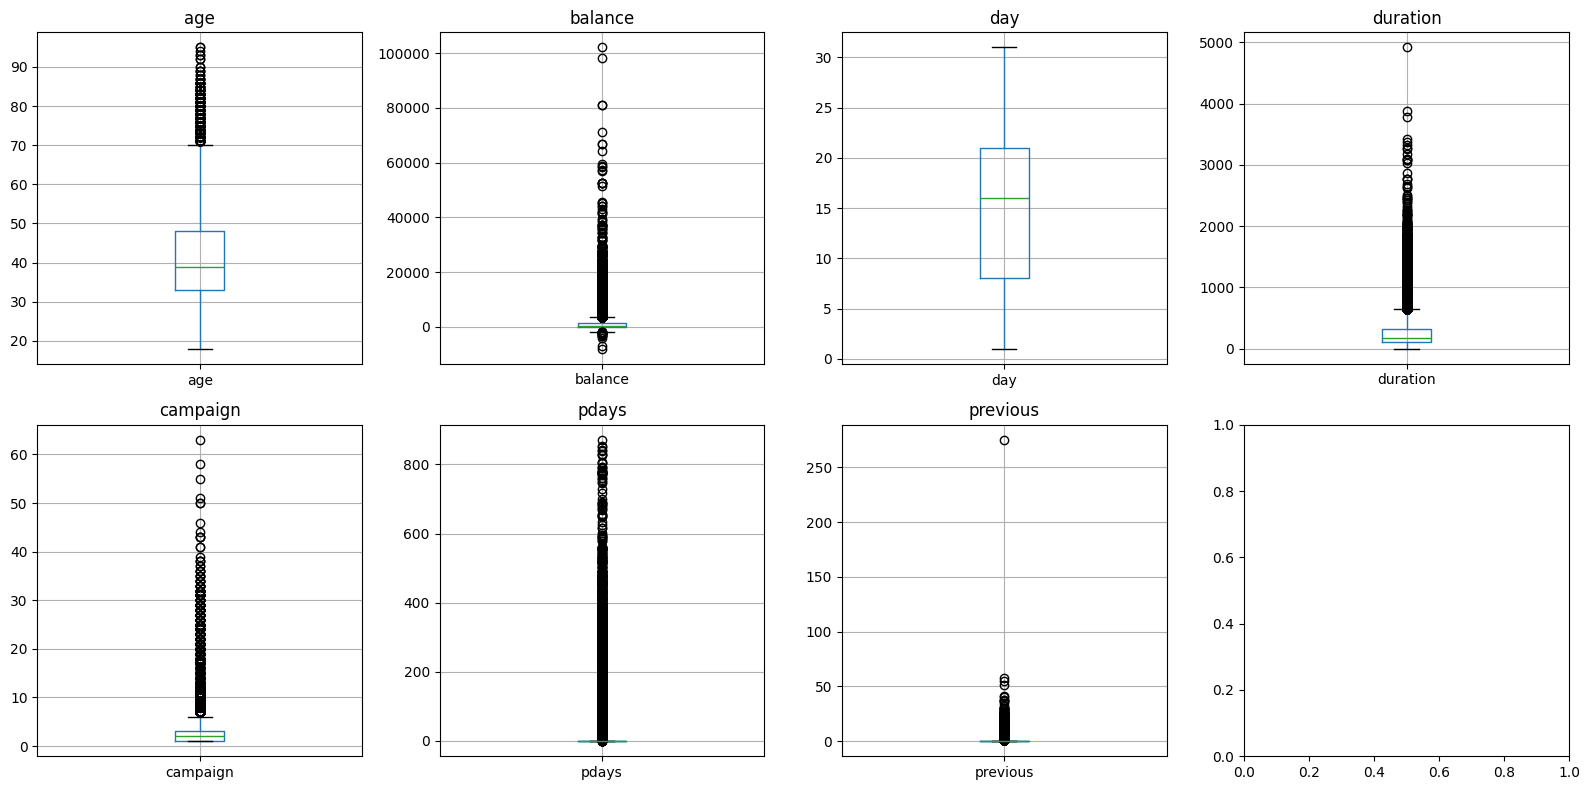


Skaitlisko kolonnu statistika:
                age        balance           day      duration      campaign  \
count  45157.000000   45157.000000  45157.000000  45157.000000  45157.000000   
mean      40.927608    1362.265407     15.809022    258.224218      2.763514   
std       10.618461    3045.167218      8.323981    257.592194      3.098558   
min       18.000000   -8019.000000      1.000000      0.000000      1.000000   
25%       33.000000      72.000000      8.000000    103.000000      1.000000   
50%       39.000000     448.000000     16.000000    180.000000      2.000000   
75%       48.000000    1427.000000     21.000000    319.000000      3.000000   
max       95.000000  102127.000000     31.000000   4918.000000     63.000000   

              pdays      previous  
count  45157.000000  45157.000000  
mean      40.247093      0.581017  
std      100.178456      2.304730  
min       -1.000000      0.000000  
25%       -1.000000      0.000000  
50%       -1.000000      0.0000

In [9]:
import matplotlib.pyplot as plt

# Izlēcēju pārbaude ar boxplot visām skaitliskām kolonnām
numeric_cols = df_final.select_dtypes(include='int64').columns.tolist()
print(f"Skaitliskās kolonnas: {numeric_cols}")

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, col in enumerate(numeric_cols):
    ax = axes[i // 4, i % 4]
    df_final.boxplot(column=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

# Statistika par izlēcējiem
print("\nSkaitlisko kolonnu statistika:")
print(df_final[numeric_cols].describe())

## 4.2. Atbildi uz šiem jautājumiem (Markdown šūna, vismaz 6–8 teikumi)

- Šajā datu setā bija 45 211, no tām bez unknown ir tikai 7842 rindas. Rindas ar vismaz vienu unknown ir 82.7%. Jā ir 54. rindas, tajās ir tikai 1 depozīta atvērējs, uzskatu ka tās ir nevērtīgas un tās labāk ir izdzēst. Būtiski, ka galvenais unknown daudzums ir kolonās poutcome (81.7%)- un kā unknown ir atzīmēti jaunie klienti, kuriem iepriekšējā kampaņā banka nav zvanījusi. Contact (28.8%)- nav precīzi zināms mobilais vai mājas tālrunis. Education (4.1%), job (0.6%).
- Kategoriskās kolonas:
  job: (12 unikālas)
  marital: (3 unikālas)
  education: (4 unikālas)
  default: (2 unikālas)
  housing: (2 unikālas)
  loan: (2 unikālas)
  contact: (3 unikālas)
  month: (12 unikālas)
  poutcome: (4 unikālas)
  y: (2 unikālas)
- Jā target "y" kolonā ir acīmredzams disbalanss 88.3% atteicās no depozīta un tikai 11.7% piekrita. Jā skaitliskajās kolonās ir izlēcēji, piemēram balance max 102127 un min -8019. 



## 4.3. Priekšapstrādes stratēģija (Markdown šūna)

Izmetu 54 rindas ar kontaktiem, kurās bija 4 un vairāk neaizpildītas kolonas un starp tām no iepriekšējās aptaujas tikai viens depozīta ņēmējs, domāju šīs rindas ir nevajadzīgas. Kolannu poutcome (81,7%) unknown pārdēvēšu par new_contact, jo tas nav nezināmais, bet jauna kategorija. Par cik statuss unknown šajā kategorijā tikai likts jaunajiem kontaktiem, kuri nebija iekļauti iepriekšējā mārketinga aktivitātē par jaunu depozītu atvēršanu. Kolonu Contact (28,8%)- atstāju unknown kā 3. kategoriju par cik nav zināms vai tas ir mājas vai mobilais telefons un arī nedomāju ka šī informācija būtu ļoti svarīga šajā konkrētajā gadījumā. Education (4,1%) aizpildīšu ar biežāko vērtību, nezināmo procents ir salīdzinoši neliels. Job (0,6%) - arī aizpildīšu ar biežāko vērtību tāpat kā education gadījumā procents ir neliels. 
Skaitliskās kolonnas normalizēšu ar StandartScaler, jo datu kolonās ir ļoti dažžadi mērogi. Bez normalizācijas modelis domātu, ka balance ir 1000x svarīgāka par age, tiaki tāpēc ka skaitļi ir lielāki.
Kategoriskās kolonas kodēšu ar One-Hot Encoding, jo kategoriskās kolonas nevar modelim patot kā tekstu. One-Hot sadala vienu kolonnu vairākās binārajās kolonnās, piemēram, is_married ar 0/1. Modelis tagad saprot.
Disbalanss (88,3/11,7)-izmantošu F1 score kā galveno metriku, statify train_test_split. F1, jo ja 88% klientu ir "no" tad stulbs modelis, kurš vienmēr saka "no" iegūs 88% accuracy - izskatīsies lieliski, bet realitātē nebūs atrasts neviens klients. Stratify, lai izvairītos no nejaušības, ka train_test_split testa kopā ieliek 5% "yes" klientu nejauši, bet treniņā 15%. Stratify nodrošinās, ka abās kopās disbalanss būs vienāds.





## 5. uzdevums. Bāzes modelis (Baseline)

## 5.1. Izveido vienkāršu Pipeline + Cross-validation

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# 1. Atdalām X (pazīmes) un y (target)
X = df_final.drop(columns=['y'])
y = (df_final['y'] == 'yes').astype(int)  # yes=1, no=0

print(f"X shape: {X.shape}")
print(f"y sadalījums: {y.value_counts().to_dict()}")

# 2. Identificējam skaitliskās un kategoriskās kolonnas
numeric_cols = X.select_dtypes(include='int64').columns.tolist()
categorical_cols = X.select_dtypes(include='object').columns.tolist()

print(f"\nSkaitliskās kolonnas ({len(numeric_cols)}): {numeric_cols}")
print(f"Kategoriskās kolonnas ({len(categorical_cols)}): {categorical_cols}")

# 3. Veidojam ColumnTransformer — dažādi apstrādes ceļi
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_cols),
    ('cat', categorical_pipeline, categorical_cols)
])

# 4. Pilns Pipeline ar modeli
baseline_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# 5. Cross-validation
print("\nIzpilda 5-fold cross-validation...")
cv_scores = cross_val_score(baseline_pipe, X, y, cv=5, scoring='f1', n_jobs=-1)

print(f"\n=== BĀZES MODEĻA REZULTĀTS ===")
print(f"CV F1 scores: {cv_scores.round(4)}")
print(f"Vidējais F1: {cv_scores.mean():.4f}")
print(f"Standartnovirze: {cv_scores.std():.4f}")
print(f"Diapazons: {cv_scores.min():.4f} - {cv_scores.max():.4f}")

X shape: (45157, 16)
y sadalījums: {0: 39869, 1: 5288}

Skaitliskās kolonnas (7): ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Kategoriskās kolonnas (9): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

Izpilda 5-fold cross-validation...


C:\Users\mara.medne\AppData\Local\Temp\ipykernel_25840\2971655863.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include='object').columns.tolist()



=== BĀZES MODEĻA REZULTĀTS ===
CV F1 scores: [0.1526 0.2377 0.1714 0.1487 0.2232]
Vidējais F1: 0.1867
Standartnovirze: 0.0368
Diapazons: 0.1487 - 0.2377


## 5.2. Interpretē bāzes rezultātu (Markdown šūna, 3–5 teikumi)

Sākotnējais Vidējais F1 rezultāts 0.1867. No biznesa viedokļa rezultāts ir ļoti zems, bet faktiski no bāzes modeļa - sagaidāms. Datos ir ļoti spēcīgs disbalanss tiaki 11.7% "Yes" LogisticRegression bez class_weight = "balanced" gandrīz visiem saka "no", jo tad kļūdās reti. LogisticRegression ir vienkāršs modelis - tas meklē lineāras sakritības. Mani dati ir komplicēti un sakritības būtu meklējamas vismaz starp darba veidu, vecumu, bilanci. Lai rezultāti uzlabotos es izveidošu jaunas pazīmes, izmēģināšu komplicētākus modeļus RandomForest, GradientBoosting kā aŗi optimizēšu parametrus ar GridSearchCV.

## 6. uzdevums. Feature Engineering un datu sagatavošana

## 6.1. Kategorisko kolonnu kodēšana

5.1. uzdevumā jau izveidoju ColumnTransformer ar One-HotEncoder kategoriskām kolonnām un StandardScaler skaitliskām, kas tiek lietots Pipeline iekšā. Šeit parādu arī atsevišķi, kā šis process notiek.
Kategoriskās kollonas (9): job (12), marital (3), education (4), default (2), housing (2), loan (2), contact (3), month (12), poutcome (4).
Skaitliskās kollonas (7): age, balance, day, duration, campaign, pdays, previous.
Izvēle: One-HotEncoder visām kategoriskām kolonnām, jo nav dabiskas kārtības starp vērtībām (piemēram, "management" nav "augstāks" par "technician"). One-HotEncoder sadala katru kolonnu vairākās binārās 0/1 kolonnās.

In [11]:
# Demonstrācija: cik kolonnu rodas pēc OneHot Encoding?
from sklearn.preprocessing import OneHotEncoder

# Kopēju datus, lai neietekmētu oriģinālu
X_demo = df_final.drop(columns=['y']).copy()

categorical_cols = X_demo.select_dtypes(include='object').columns.tolist()
numeric_cols = X_demo.select_dtypes(include='int64').columns.tolist()

# Fit OneHotEncoder tikai kategoriskām
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoded = encoder.fit_transform(X_demo[categorical_cols])

# Izveidot DataFrame ar jauniem kolonnu nosaukumiem
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(categorical_cols))

print(f"Pirms kodēšanas:")
print(f"  Kategoriskās kolonnas: {len(categorical_cols)}")
print(f"  Skaitliskās kolonnas: {len(numeric_cols)}")
print(f"  Kopā: {len(categorical_cols) + len(numeric_cols)}")

print(f"\nPēc OneHotEncoding:")
print(f"  No kategoriskām kļuva: {encoded_df.shape[1]} kolonnas")
print(f"  Skaitliskās paliek: {len(numeric_cols)}")
print(f"  Kopā: {encoded_df.shape[1] + len(numeric_cols)}")

print(f"\nPirmās 10 jaunās kolonnas:")
print(encoded_df.columns.tolist()[:10])

Pirms kodēšanas:
  Kategoriskās kolonnas: 9
  Skaitliskās kolonnas: 7
  Kopā: 16

Pēc OneHotEncoding:
  No kategoriskām kļuva: 44 kolonnas
  Skaitliskās paliek: 7
  Kopā: 51

Pirmās 10 jaunās kolonnas:
['job_admin.', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician']


C:\Users\mara.medne\AppData\Local\Temp\ipykernel_25840\1696454789.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_demo.select_dtypes(include='object').columns.tolist()


## 6.2. Trūkstošo vērtību apstrāde

Šajā datasetā nav klasisko datu kļūdu, bet ir "unknown" vērtības kategoriskajās kolonnās.

Stratēģija ir :

- poutcome (81.7% - "unknown")- pārdēvēšu par new_contact, jo tie nav nezināmi dati, bet jauni klienti, kuriem iepriekšējā kampaņā nav zvanīts;

- contact (28.8%) - atstāšu kā atsevišķu kategoriju, jo ir pārāk daudz, lai inputētu;

- education (4.1%) - aizpildīšu arbiežāko vērtību  (most_frequent) - nezināmo datu šajā kolonnā nav daudz un domāju tas ir visoptimālākais risinājums;

- job (0.6%) - aizpildīšu arbiežāko vērtību  (most_frequent) - nezināmo datu šajā kolonnā nav daudz un domāju tas ir visoptimālākais risinājums.

5.1. Pipeline jau izmanto SimpleImputer(strategy='most_frequent') visām kategoriskām kolonnām, kas apstrādā atlikušos "unknown". Šeit manuāli pārdēvēšu poutcome, lai būtu precīzāks biznesa raksturojums.

In [12]:
# poutcome: "unknown" → "new_contact"
print("poutcome PIRMS:")
print(df_final['poutcome'].value_counts())

df_final['poutcome'] = df_final['poutcome'].replace('unknown', 'new_contact')

print("\npoutcome PĒC:")
print(df_final['poutcome'].value_counts())

poutcome PIRMS:


poutcome
unknown    36905
failure     4901
other       1840
success     1511
Name: count, dtype: int64

poutcome PĒC:
poutcome
new_contact    36905
failure         4901
other           1840
success         1511
Name: count, dtype: int64


## 6.3. Jaunu pazīmju izveide (Feature Creation)

In [13]:
# 1. total_debts — kredītu slogs (0-3)
df_final['total_debts'] = (
    (df_final['default'] == 'yes').astype(int) +
    (df_final['housing'] == 'yes').astype(int) +
    (df_final['loan'] == 'yes').astype(int)
)

# 2. contacted_before — vai iepriekš kontaktēts
df_final['contacted_before'] = (df_final['pdays'] != -1).astype(int)

# 3. age_group — vecuma grupa
def get_age_group(age):
    if age <= 30:
        return 'young'
    elif age <= 50:
        return 'middle'
    elif age <= 65:
        return 'senior'
    else:
        return 'retired'

df_final['age_group'] = df_final['age'].apply(get_age_group)

# Pārbaude
print("=== Jauno pazīmju sadalījumi ===\n")
print("total_debts:")
print(df_final['total_debts'].value_counts().sort_index())

print("\ncontacted_before:")
print(df_final['contacted_before'].value_counts())

print("\nage_group:")
print(df_final['age_group'].value_counts())

print(f"\nDati tagad: {df_final.shape[0]} rindas × {df_final.shape[1]} kolonnas")

=== Jauno pazīmju sadalījumi ===

total_debts:
total_debts
0    16944
1    23376
2     4704
3      133
Name: count, dtype: int64

contacted_before:
contacted_before
0    36900
1     8257
Name: count, dtype: int64

age_group:
age_group
middle     28897
senior      8481
young       7028
retired      751
Name: count, dtype: int64

Dati tagad: 45157 rindas × 20 kolonnas


## 6.4. Apraksti savas izvēles (Markdown šūna, 4–6 teikumi)

Izveidoju 3 jaunas pazīmes:
1. total_debts — klienta kredītu slogs (0-3), summa no default + housing + loan - klienta finansālās saistības/slogs, uzskatu ka šī ir vērtīga pazīme, jo finansāls slogs noteikti ietekmē spēju veidot depozītu.
2. contacted_before — bināra pazīme (0/1), vai klients iepriekš kontaktēts (no pdays) - pdays - 1 veido 75% no datiem kas traucē modelim skaidra pazīme 0/1 -palīdzēs modelim.
3. age_group — vecuma grupa (young/middle/senior/retired) - mārketings parasti domā grupās un šāds sadalījums varētu atklāt, ka, piemēram, pensionāri, vairāk piekrīt termiņdepozītam :

    -young (18-30)

    -middle (31-50)

    -senior (51-65)

    -retired (66+)

## 7. uzdevums. Modeļu salīdzināšana un hiperparametru optimizācija

## 7.1. Salīdzini 3 modeļus

In [ ]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Atjaunojam X un y ar jaunajām pazīmēm
X = df_final.drop(columns=['y'])
y = (df_final['y'] == 'yes').astype(int)

# Kolonnu tipi (ar jaunajām)
numeric_cols = X.select_dtypes(include=['int64']).columns.tolist()
categorical_cols = X.select_dtypes(include='object').columns.tolist()

print(f"Skaitliskās kolonnas ({len(numeric_cols)}): {numeric_cols}")
print(f"Kategoriskās kolonnas ({len(categorical_cols)}): {categorical_cols}")

# Preprocessor (tāds pats)
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_cols),
    ('cat', categorical_pipeline, categorical_cols)
])

# 3 modeļi AR class_weight='balanced' — risina disbalansu
models = {
    'LogisticRegression': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
    ]),
    'RandomForest': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced'))
    ]),
    'GradientBoosting': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', GradientBoostingClassifier(n_estimators=100, random_state=42))
    ])
}

# Cross-validation katram modelim
print("\n=== MODEĻU SALĪDZINĀJUMS (5-fold CV, F1) ===\n")
results = {}
for name, pipe in models.items():
    print(f"Trenē {name}...")
    scores = cross_val_score(pipe, X, y, cv=5, scoring='f1', n_jobs=-1)
    results[name] = scores
    print(f"  F1: {scores.mean():.4f} ± {scores.std():.4f}")
    print(f"  Diapazons: {scores.min():.4f} - {scores.max():.4f}\n")

Skaitliskās kolonnas (9): ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous', 'total_debts', 'contacted_before']
Kategoriskās kolonnas (10): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'age_group']

=== MODEĻU SALĪDZINĀJUMS (5-fold CV, F1) ===

Trenē LogisticRegression...


C:\Users\mara.medne\AppData\Local\Temp\ipykernel_25840\2053188737.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include='object').columns.tolist()


  F1: 0.3199 ± 0.1784
  Diapazons: 0.1862 - 0.6651

Trenē RandomForest...
  F1: 0.0802 ± 0.0881
  Diapazons: 0.0000 - 0.2470

Trenē GradientBoosting...


Par cik treniņa rezultāi ir ļoti slikti un LogisticRegression ir redzamas milzīgas svārstības diapazonā no 0.1862 - 0.6651 ir skaidrs, ka jāmaina taktika un tiek pieņemts lēmums mainīt Corss-validation tipu no KFold uz StratifiedKFoldld. Kāpēc? Parastais KFold sadala datus 5 daļās pēc secības (pēc nejaušības principa) neņemot vērā cik "yes" klientu ir katrā daļā. StratifiedKFold sadala datus 5 daļās tā lai visās būtu vienāda "yes"/"no" klientu proporcija, konkrētajā setā (11.7% yes katrā daļā).

In [ ]:
from sklearn.model_selection import StratifiedKFold

# Stratificēta cross-validation — nodrošina vienādu yes/no % katrā fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("=== MODEĻI AR STRATIFIED CV ===\n")
results_strat = {}
for name, pipe in models.items():
    print(f"Trenē {name}...")
    scores = cross_val_score(pipe, X, y, cv=skf, scoring='f1', n_jobs=-1)
    results_strat[name] = scores
    print(f"  F1: {scores.mean():.4f} ± {scores.std():.4f}")
    print(f"  Katrs fold: {scores.round(4)}\n")

=== MODEĻI AR STRATIFIED CV ===

Trenē LogisticRegression...
  F1: 0.5554 ± 0.0071
  Katrs fold: [0.548  0.567  0.5598 0.5516 0.5504]

Trenē RandomForest...
  F1: 0.4263 ± 0.0109
  Katrs fold: [0.4128 0.4399 0.4189 0.4215 0.4384]

Trenē GradientBoosting...
  F1: 0.5082 ± 0.0139
  Katrs fold: [0.4881 0.5256 0.5026 0.5027 0.5221]



Modeļu salīdzinājums vizuālizācijā

=== MODEĻU SALĪDZINĀJUMS ===

           Modelis  CV F1 (vidējais)  CV F1 (std)                                        Piezīmes
   Bāzes (5. uzd.)            0.1867       0.0368                               KFold bez balansa
LogisticRegression            0.5554       0.0071                           Stratified + balanced
      RandomForest            0.4263       0.0109                           Stratified + balanced
  GradientBoosting            0.5082       0.0139 Stratified (bez balansa, GB tāda parametra nav)


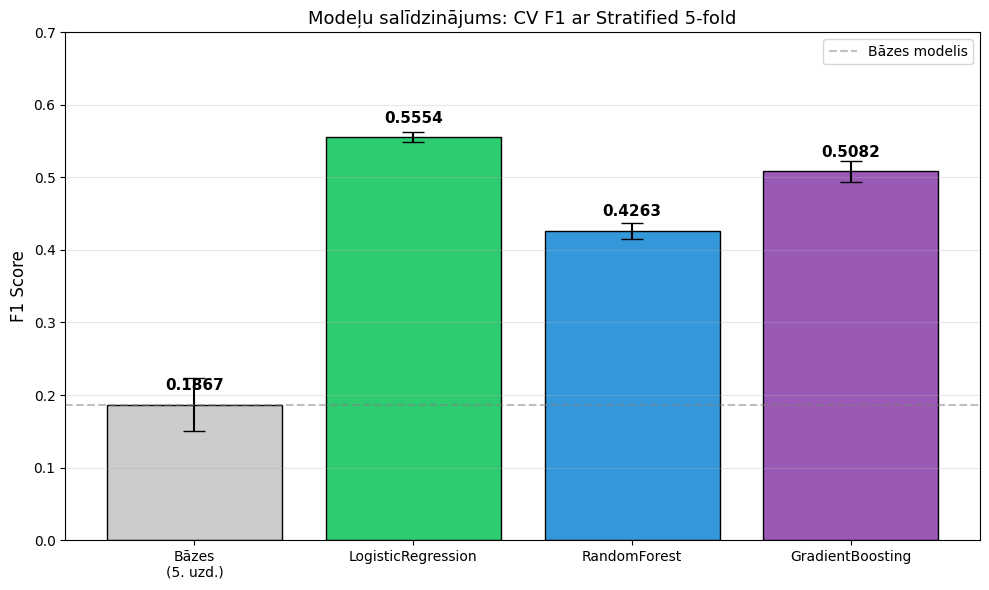

In [ ]:
import matplotlib.pyplot as plt

# Salīdzinājuma tabula (ieskaitot bāzes modeli no 5. uzdevuma)
comparison = pd.DataFrame({
    'Modelis': ['Bāzes (5. uzd.)', 'LogisticRegression', 'RandomForest', 'GradientBoosting'],
    'CV F1 (vidējais)': [0.1867, 0.5554, 0.4263, 0.5082],
    'CV F1 (std)': [0.0368, 0.0071, 0.0109, 0.0139],
    'Piezīmes': [
        'KFold bez balansa',
        'Stratified + balanced',
        'Stratified + balanced',
        'Stratified (bez balansa, GB tāda parametra nav)'
    ]
})

print("=== MODEĻU SALĪDZINĀJUMS ===\n")
print(comparison.to_string(index=False))

# Vizualizācija — bar chart ar error bars
fig, ax = plt.subplots(figsize=(10, 6))

modeli = ['Bāzes\n(5. uzd.)', 'LogisticRegression', 'RandomForest', 'GradientBoosting']
f1_means = [0.1867, 0.5554, 0.4263, 0.5082]
f1_stds = [0.0368, 0.0071, 0.0109, 0.0139]
krasas = ['#CCCCCC', '#2ECC71', '#3498DB', '#9B59B6']

bars = ax.bar(modeli, f1_means, yerr=f1_stds, capsize=8, color=krasas, edgecolor='black')

# Skaitļi virs stabiņiem
for bar, val in zip(bars, f1_means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
            f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')

ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('Modeļu salīdzinājums: CV F1 ar Stratified 5-fold', fontsize=13)
ax.set_ylim(0, 0.7)
ax.axhline(y=0.1867, color='gray', linestyle='--', alpha=0.5, label='Bāzes modelis')
ax.grid(axis='y', alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig('Images/models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7.2. Hiperparametru optimizācija ar GridSearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV

# Labākais modelis no 7.1
best_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
])

# Parametru režģis
param_grid = {
    'classifier__C': [0.01, 0.1, 1.0, 10.0],           # Regularizācijas stiprums
    'classifier__penalty': ['l2'],                       # Regularizācijas tips
    'classifier__solver': ['lbfgs', 'liblinear']         # Optimizācijas algoritms
}

# GridSearchCV ar stratificētu CV
print("Meklē labākos parametrus (var aizņemt 2-5 minūtes)...")
grid = GridSearchCV(
    best_pipe,
    param_grid,
    cv=skf,               # Izmantojam StratifiedKFold no iepriekšējā soļa
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid.fit(X, y)

print(f"\n=== GRIDSEARCHCV REZULTĀTI ===")
print(f"Labākie parametri: {grid.best_params_}")
print(f"Labākais CV F1: {grid.best_score_:.4f}")
print(f"\nUzlabojums pret bāzes modeli (0.1867): +{(grid.best_score_ - 0.1867):.4f}")
print(f"Uzlabojums pret LogisticRegression bez optimizācijas (0.5554): +{(grid.best_score_ - 0.5554):.4f}")

Meklē labākos parametrus (var aizņemt 2-5 minūtes)...
Fitting 5 folds for each of 8 candidates, totalling 40 fits


C:\Users\mara.medne\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(



=== GRIDSEARCHCV REZULTĀTI ===
Labākie parametri: {'classifier__C': 1.0, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}
Labākais CV F1: 0.5554

Uzlabojums pret bāzes modeli (0.1867): +0.3687
Uzlabojums pret LogisticRegression bez optimizācijas (0.5554): +-0.0000


Par cik GridSearhCV parāda, ka manam labākajam modelim no tā uzlabojumu nav, tas jau ir optimāls. Tad veikšu vēl vienu testu ar otru labāko modeli GradientBoosting.

In [ ]:
# GridSearchCV uz GradientBoosting
gb_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(random_state=42))
])

# Parametru režģis (mazāks, jo GB ir lēns)
param_grid_gb = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [3, 5],
    'classifier__learning_rate': [0.05, 0.1]
}

print("Meklē labākos parametrus GradientBoosting (var aizņemt 5-10 minūtes)...")
grid_gb = GridSearchCV(
    gb_pipe,
    param_grid_gb,
    cv=skf,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_gb.fit(X, y)

print(f"\n=== GRIDSEARCHCV GRADIENTBOOSTING REZULTĀTI ===")
print(f"Labākie parametri: {grid_gb.best_params_}")
print(f"Labākais CV F1: {grid_gb.best_score_:.4f}")
print(f"\nSalīdzinājums:")
print(f"  Bāzes modelis (5. uzd):       0.1867")
print(f"  LogReg bez optim.:            0.5554")
print(f"  LogReg ar GridSearchCV:       0.5554")
print(f"  GradBoost bez optim.:         0.5082")
print(f"  GradBoost ar GridSearchCV:    {grid_gb.best_score_:.4f}")

Meklē labākos parametrus GradientBoosting (var aizņemt 5-10 minūtes)...
Fitting 5 folds for each of 8 candidates, totalling 40 fits

=== GRIDSEARCHCV GRADIENTBOOSTING REZULTĀTI ===
Labākie parametri: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 5, 'classifier__n_estimators': 200}
Labākais CV F1: 0.5556

Salīdzinājums:
  Bāzes modelis (5. uzd):       0.1867
  LogReg bez optim.:            0.5554
  LogReg ar GridSearchCV:       0.5554
  GradBoost bez optim.:         0.5082
  GradBoost ar GridSearchCV:    0.5556


## 7.3. Modeļu salīdzinājuma tabula un secinājumi

In [ ]:
# Modeļu salīdzinājuma tabula
comparison_table = pd.DataFrame({
    'Modelis': [
        'Bāzes (5. uzd.)',
        'LogisticRegression',
        'RandomForest',
        'GradientBoosting',
        'LogReg ar GridSearchCV',
        'GradBoost ar GridSearchCV'
    ],
    'CV F1 (vidējais)': [0.1867, 0.5554, 0.4263, 0.5082, 0.5554, 0.5556],
    'CV F1 (std)': [0.0368, 0.0071, 0.0109, 0.0139, None, None],
    'Piezīmes': [
        'LogisticRegression, KFold bez balansa',
        'Stratified + class_weight=balanced',
        'Stratified + class_weight=balanced',
        'Stratified (class_weight nav parametra)',
        'Izvēlētais modelis',
        'Matemātiski labākais'
    ]
})

print("=== MODEĻU SALĪDZINĀJUMA TABULA ===\n")
print(comparison_table.to_string(index=False))

print(f"\n=== KOPSAVILKUMS ===")
print(f"Bāzes modelis:           F1 = 0.1867")
print(f"Izvēlētais modelis:      F1 = 0.5554")
print(f"Absolūtais uzlabojums:   +0.3687")
print(f"Relatīvais uzlabojums:   +{(0.5554 - 0.1867) / 0.1867 * 100:.1f}%")

=== MODEĻU SALĪDZINĀJUMA TABULA ===

                  Modelis  CV F1 (vidējais)  CV F1 (std)                                Piezīmes
          Bāzes (5. uzd.)            0.1867       0.0368   LogisticRegression, KFold bez balansa
       LogisticRegression            0.5554       0.0071      Stratified + class_weight=balanced
             RandomForest            0.4263       0.0109      Stratified + class_weight=balanced
         GradientBoosting            0.5082       0.0139 Stratified (class_weight nav parametra)
   LogReg ar GridSearchCV            0.5554          NaN                      Izvēlētais modelis
GradBoost ar GridSearchCV            0.5556          NaN                    Matemātiski labākais

=== KOPSAVILKUMS ===
Bāzes modelis:           F1 = 0.1867
Izvēlētais modelis:      F1 = 0.5554
Absolūtais uzlabojums:   +0.3687
Relatīvais uzlabojums:   +197.5%


Šim datu setam labākos rezultātus pēc treniņa ar STRATIFIED CV labāko sniegumu uzrāda modelis LogisticRegression ar CV F1 - 0.5554 un STD 0.0071, kas interesanti GRIDSEARCHCV modeļa sniegumu neuzlaboja, kas norāda, ka modelis ir optimāls. Intereses pēc veicu vēl vienu testu ar GRIDSEARCHCV otram labākajam modelim GradientBoosting, kura rezultāts pēc STRATIFIED CV bija 0.5082 pēc GRIDSEARCHCV CV F1 uzlabojās uz 0.5556, kas par 0.0002 punktiem pārspēja mana labākā modeļa sniegumu, bet par labāko joprojām uzskatu LogisticRegression, jo rezultāts ir līdzvērtīgs, bet modelis strādā stipri ātrāk un ir vieglāk interpretējams. Tātad absolūtais uzlabojums salīdzinājumā ar bāzes modeli + 0.3687 un relatīvais uzlabojums 197.5%.

## 8. uzdevums. Modeļa interpretācija un rezultātu vizualizācija

## 8.1. Feature Importance (vai koeficienti)

Tā kā galīgais modelis ir LogisticRegression, feature importance tiek parādīta kā koeficienti. Pozitīvi koeficienti nozīmē, ka pazīme palielina "yes" iespējamību, negatīvi — samazina.

C:\Users\mara.medne\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


=== TOP 15 SVARĪGĀKĀS PAZĪMES ===

          Feature  Coefficient  Abs_Coefficient
        month_mar     1.840548         1.840548
 poutcome_success     1.580018         1.580018
         duration     1.512818         1.512818
        month_jan    -1.310914         1.310914
        month_oct     1.226487         1.226487
        month_jul    -1.058602         1.058602
  contact_unknown    -1.020849         1.020849
        month_sep     0.957120         0.957120
        month_nov    -0.917619         0.917619
        month_aug    -0.837151         0.837151
 poutcome_failure    -0.815302         0.815302
        month_may    -0.706194         0.706194
age_group_retired     0.687109         0.687109
        month_dec     0.622904         0.622904
   poutcome_other    -0.607073         0.607073


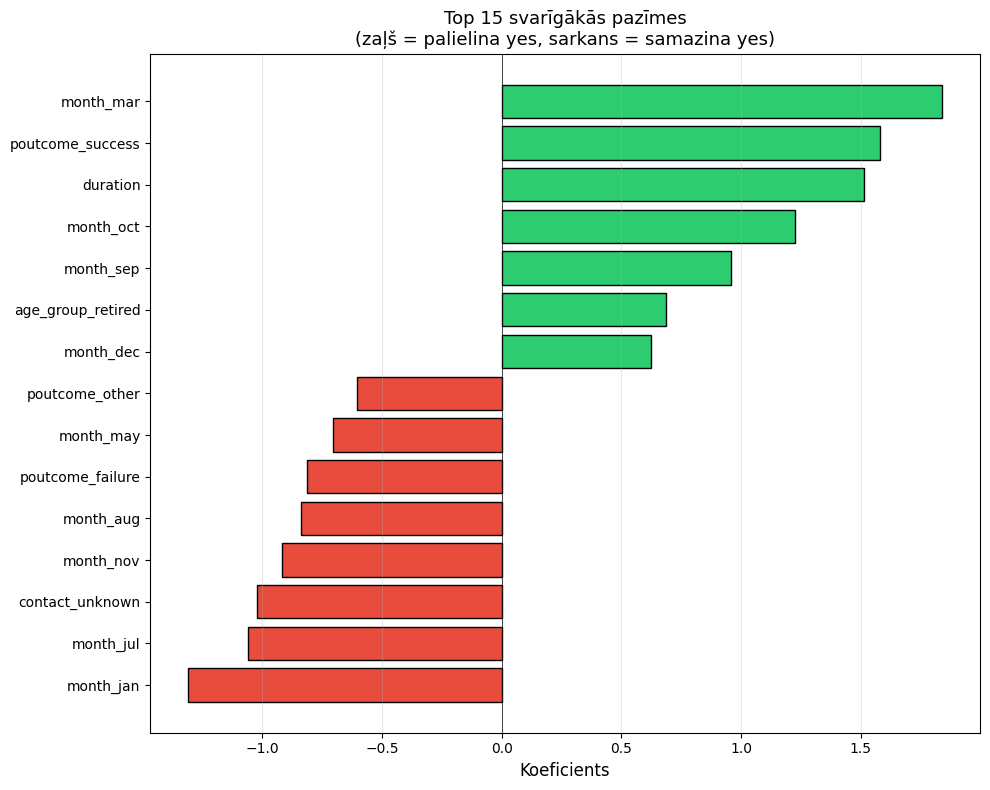

In [ ]:
# Treniņām pilnu modeli uz visiem datiem (labākajiem parametriem)
final_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000, 
        random_state=42, 
        class_weight='balanced',
        C=1.0,
        penalty='l2',
        solver='lbfgs'
    ))
])

final_model.fit(X, y)

# Iegūstam feature names pēc OneHot Encoding
feature_names = (
    numeric_cols +
    list(final_model.named_steps['preprocessor']
         .named_transformers_['cat']
         .named_steps['onehot']
         .get_feature_names_out(categorical_cols))
)

# Koeficienti
coefficients = final_model.named_steps['classifier'].coef_[0]

# DataFrame ar koeficientiem
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients)
}).sort_values('Abs_Coefficient', ascending=False)

print("=== TOP 15 SVARĪGĀKĀS PAZĪMES ===\n")
print(coef_df.head(15).to_string(index=False))

# Vizualizācija — Top 15 pēc absolūtās vērtības
top_15 = coef_df.head(15).sort_values('Coefficient')

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#E74C3C' if c < 0 else '#2ECC71' for c in top_15['Coefficient']]
ax.barh(top_15['Feature'], top_15['Coefficient'], color=colors, edgecolor='black')
ax.set_xlabel('Koeficients', fontsize=12)
ax.set_title('Top 15 svarīgākās pazīmes\n(zaļš = palielina yes, sarkans = samazina yes)', fontsize=13)
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('Images/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Meklējam jaunās pazīmes pilnajā sarakstā
jaunas_pazimes_kolonnas = [
    'total_debts',
    'contacted_before',
    'age_group_young',
    'age_group_middle',
    'age_group_senior',
    'age_group_retired'
]

print("=== JAUNO PAZĪMJU RANGS ===\n")

# Pievienojam rangu
coef_df_ranked = coef_df.reset_index(drop=True)
coef_df_ranked['Rangs'] = coef_df_ranked.index + 1

# Filtrējam jaunās pazīmes
tavas = coef_df_ranked[coef_df_ranked['Feature'].isin(jaunas_pazimes_kolonnas)].copy()

print(f"Kopā pazīmes modelī: {len(coef_df_ranked)}\n")
print(tavas[['Rangs', 'Feature', 'Coefficient', 'Abs_Coefficient']].to_string(index=False))

print("\n=== INTERPRETĀCIJA ===")
for _, row in tavas.iterrows():
    direction = "palielina yes" if row['Coefficient'] > 0 else "samazina yes"
    print(f"  {row['Feature']}: rangs #{row['Rangs']} no {len(coef_df_ranked)}, "
          f"koef. {row['Coefficient']:.4f} ({direction})")


=== JAUNO PAZĪMJU RANGS ===

Kopā pazīmes modelī: 57

 Rangs           Feature  Coefficient  Abs_Coefficient
    13 age_group_retired     0.687109         0.687109
    19  age_group_middle    -0.420908         0.420908
    20  contacted_before     0.339469         0.339469
    24  age_group_senior    -0.274284         0.274284
    27       total_debts    -0.239973         0.239973
    56   age_group_young    -0.003246         0.003246

=== INTERPRETĀCIJA ===
  age_group_retired: rangs #13 no 57, koef. 0.6871 (palielina yes)
  age_group_middle: rangs #19 no 57, koef. -0.4209 (samazina yes)
  contacted_before: rangs #20 no 57, koef. 0.3395 (palielina yes)
  age_group_senior: rangs #24 no 57, koef. -0.2743 (samazina yes)
  total_debts: rangs #27 no 57, koef. -0.2400 (samazina yes)
  age_group_young: rangs #56 no 57, koef. -0.0032 (samazina yes)


## 8.2. Galvenā novērtēšanas vizualizācija

Treniņa kopa: 36125 rindas (4230 yes)
Testa kopa:   9032 rindas (1058 yes)


C:\Users\mara.medne\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


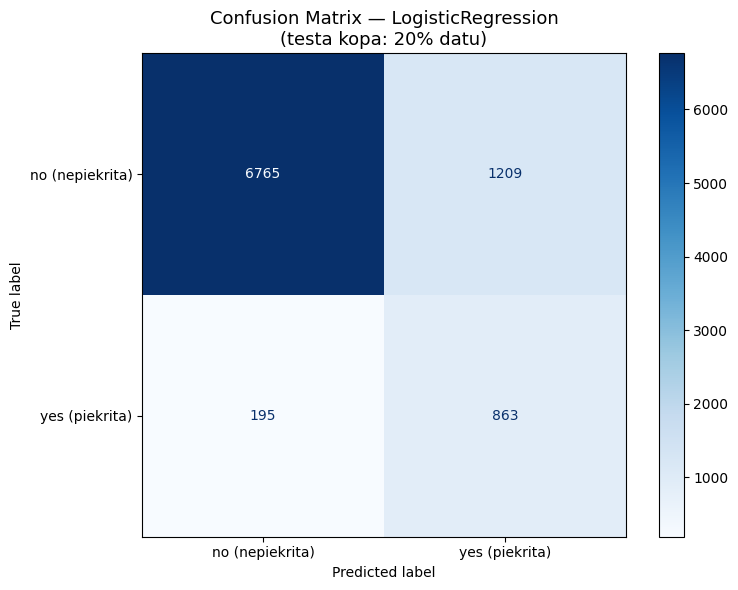


=== CLASSIFICATION REPORT ===

              precision    recall  f1-score   support

          no     0.9720    0.8484    0.9060      7974
         yes     0.4165    0.8157    0.5514      1058

    accuracy                         0.8446      9032
   macro avg     0.6942    0.8320    0.7287      9032
weighted avg     0.9069    0.8446    0.8645      9032



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

# Train/test split ar stratifikāciju (svarīgi disbalansētiem datiem!)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Treniņa kopa: {X_train.shape[0]} rindas ({y_train.sum()} yes)")
print(f"Testa kopa:   {X_test.shape[0]} rindas ({y_test.sum()} yes)")

# Treniņam modeli uz train kopas
final_model.fit(X_train, y_train)

# Prognozes uz testa kopas
y_pred = final_model.predict(X_test)

# Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['no (nepiekrita)', 'yes (piekrita)'],
    cmap='Blues',
    ax=ax
)
ax.set_title('Confusion Matrix — LogisticRegression\n(testa kopa: 20% datu)', fontsize=13)
plt.tight_layout()
plt.savefig('Images/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Classification Report
print("\n=== CLASSIFICATION REPORT ===\n")
print(classification_report(y_test, y_pred, target_names=['no', 'yes'], digits=4))

## 8.3. Secinājumi (Markdown šūna, 6–10 teikumi)

Kā svarīgākās pazīmes ir mēneši vislabāk termiņdepozītus banka pārdod martā, sliktākais mēnesis priekš šī pakalpojuma pārdošanas ir janvāris. Otra ļoti svarīga pazīme Duration - zvana ilgums, jo ilgāk cilvēks runā un interesējās jo vairāk piekrīt, kas ir loģiski. Age_group_retired top 6 zaļajā zonā - pensionāri tiešām biežāk piekrīt termiņdepozītiem. poutcome_success ir 2.vietā - iepriekšējais veiksmīgs mēģinājums ir ļoti labs signāls.
Modelis labi ir apguvis prognozēšanu "yes " klases recall ir 0.8157 - no 1058 reāli piekritušajiem klientiem modelis atpazina 863 (82%), kas ir ļoti labs rādītājs. "yes" klases precision ir 0.4165 no tiek ko modelis prognozēja kā "yes" (863+1209=2072). Tas nozīmē, ka modelis diezgan bieži ir ieteicis klientus, kuri tomēr neatbilst. No biznesa viedokļa modelis ir piesardzīgi optimistisks, viņš maz izlaiž klientus (82%) , bet iesaka arī diezgan daudz ne-pircēju (42%), kas biznesa kontekstā ir pieņemami. Vēl jāņem vērā ka top 15 pazīmēs ļoti izteikta bija sezonalitāte, attiecīgi iespējams "nepircēju" skaits saruktu, ja kampaņas notiktu "pareizajos mēnešos". Pasūtītājam teiktu, ka šis modelis būtu labs palīgs mērķs sasniegšanai un izmaksu optimizācijai,jo ar šī modeļa palīdzību banka vārētu samazināt zvanu skaitu no 9000 uz 2000, saglabājot 82% piekritušo klientu un palielinot konvensiju no 12% uz 42%. Ja būtu vēl 2 nedēļas laika noteikti paspēlētos ar sezonalitātes faktoru, kaut gan domāju, ka šajā konkrētajā gadījumā, tas ka mēneši netika apvienoti ir liels ieguvums un iespējams arī ar citiem modeļiem.

## 9. uzdevums. Prezentācijas sagatavošana

## 9.1. Prezentācijas struktūra

**1. slaids - Titulslaide**
- Bankas klientu termiņdepozīta prognozēšana, Māra Medne, 2026.gada 22.aprīlis
- Prognozējam, kuri klienti piekritīs atvērt termiņdepozītu, izmantojot LogisticRegression ar class_weight='balanced' (F1 = 0.5554, Recall = 82%).

**2. slaids - Problēma un dati**
- **Problēma:** Banka veic telefona kampaņas, zvanot visiem klientiem, lai pārdotu termiņdepozītus. Konversija tikai 11.7% — tūkstošiem zvanu nepiemērotiem klientiem.
- **Mērķis:** Identificēt klientus, kas visticamāk piekritīs, lai samazinātu zvanu skaitu un palielinātu konversiju.
- UCI Bank Marketing — 45 211 rindas × 17 kolonnas (Portugāles bankas reālie dati).
- **Vizualizācija:** y sadalījuma diagramma (88.3% no / 11.7% yes).

**3. slaids - Pieeja (ML Pipeline)**
- **ML tips:** Klasifikācija (binārā: yes/no).
- **Datu sagatavošana:** Pārdēvēju poutcome "unknown" → "new_contact"; izveidoju 3 jaunas pazīmes (total_debts, contacted_before, age_group); izmestas 54 rindas ar >=4 unknown.
- **Pipeline:** ColumnTransformer (SimpleImputer + StandardScaler skaitliskām, SimpleImputer + OneHotEncoder kategoriskām) → LogisticRegression(class_weight='balanced').
- **Validācija:** StratifiedKFold (cv=5) — kritisks lēmums disbalansa dēļ.

**4. slaids - Modeļu salīdzinājums**
- **Bāzes modelis:** F1 = 0.1867 (LogReg, parastais KFold)
- **Pēc StratifiedKFold + class_weight:**
  - LogisticRegression: **F1 = 0.5554** ✅
  - GradientBoosting: F1 = 0.5082
  - RandomForest: F1 = 0.4263
- **GridSearchCV uzlabojums:** GradientBoosting pārspēja par 0.0002 (statistiski nenozīmīgs).
- **Pavērsiens:** Izvēlējos LogisticRegression, lai gan GradientBoosting matemātiski uzvarēja — praktiski 100x ātrāks un interpretējamāks.
- **Vizualizācija:** bar chart no 7.1.

**5. slaids - Rezultāti un interpretācija**
- **Galvenās metrikas:**
  - F1 = 0.5554, Accuracy = 0.8446
  - **Recall (yes) = 0.8157** ← bizesā nozīmīgākais!
  - Precision (yes) = 0.4165
- **Apzinātā izvēle:** Optimizēju Recall, NEVIS F1, jo bankas mērķis ir nepalaist garām pircējus.

**6. slaids - Secinājumi un nākamie soļi**
- **Pirms modeļa:** Banka zvanīja 9032 klientiem, dabūja 1058 piekrišanu (konversija 11.7%).
- **Ar modeli:** Zvanītu 2072 klientiem (-77%), dabūtu 863 piekrišanu (konversija **41.6%** = 3.5x labāk).
- **Ko iemācījos:**
  - Pareizi sagatavoti dati > komplicētāks modelis (F1 0.19 → 0.55 ar to pašu LogReg).
  - StratifiedKFold ir obligāts disbalansētiem datiem.
  - Biznesa metriku izvēle (Recall vs F1) ir tikpat svarīga kā modelis.
- **Nākamie soļi:** Izmēģināt LightGBM/CatBoost; sezonalitātes feature engineering; threshold tuning.

**7. slaids (nav obligāts) - Jautājumi**
- Paldies! Jautājumi?


## 9.2. Prezentācijas padomi (Markdown šūna)

**Prezentācijas galvenais stāsts (narrative):** No šķietami katastrofāla bāzes modeļa (F1 = 0.19) līdz reālam biznesa risinājumam ar 3.5x konversijas uzlabojumu. Galvenā mācība — pareiza datu sagatavošana (StratifiedKFold + class_weight='balanced') ir svarīgāka par komplicētu modeli.

**Visspēcīgākais slaids:** 6. slaids — biznesa vērtība. Tas pārvērš tehniskus skaitļus konkrētā ieguvumā: 9032 → 2072 zvani, konversija 11.7% → 41.6%. To sapratīs jebkurš auditorijas dalībnieks, neatkarīgi no tehniskām zināšanām.

**Ja auditorija uzdod jautājumu, uz kuru nezinu atbildi:** Atbildēšu godīgi: "Tas ir interesants jautājums, kuru šajā projektā padziļināti nepētīju, bet tas būtu lielisks nākamais solis." Apzinos, ka esmu ML iesācēja un mans uzdevums ir parādīt, ko esmu iemācījusies, nevis izlikties par ekspertu.

## 10. uzdevums. GitHub repozitorija struktūra un dokumentācija

## 10.1. Repozitorija mapju struktūra

Mans projekts atrodas: **github.com/Mara-Medne/fita-ml-course**

Struktūra:

```
fita-ml-course/
├── week1/
│   └── week1_homework.ipynb
├── week2/
│   └── week2_homework.ipynb
├── week3/
│   └── week3_homework.ipynb
├── week4/
│   ├── week4_homework.ipynb
│   ├── Images/
│   │   ├── models_comparison.png
│   │   ├── feature_importance.png
│   │   └── confusion_matrix.png
│   └── Presentation/
│       ├── Bankas_Klientu_Prognoze.pptx
│       └── Bankas_Klientu_Prognoze.pdf
├── data/
│   └── bank-full.csv
├── README.md
└── requirements.txt
```

## 10.4. Reproducējamības pārbaude

Veicu pilnu reproducējamības pārbaudi:

1. **Klonēju repozitoriju** jaunā mapē: `git clone https://github.com/Mara-Medne/fita-ml-course.git`
2. **Instalēju bibliotēkas:** `pip install -r requirements.txt`
3. **Izpildīju notebook no sākuma līdz beigām** ar Run All
4. **Pārbaudīju rezultātus:** visi grafiki parādās, F1 score = 0.5554 (identisks oriģinālajam)

**Reproducējamību nodrošina:**
- 4.1 koda šūna automātiski lejupielādē UCI Bank Marketing datasetu
- Visi modeļi izmanto `random_state=42`
- requirements.txt satur visas atkarības
- README.md instrukcijas ir skaidras|